# DAY 21 : Study LLMs vs SLMs — capability gaps, latency, cost, use-case trade-offs

---

### What are LLMs and SLMs?
1. *Large Language Models (LLMs)*

Examples: GPT-4 class models, Claude, Llama 70B+

- Very large parameter counts (billions to trillions)
- Trained on massive datasets
- Strong general reasoning and knowledge

Think: “general-purpose brain”


2. *Small Language Models (SLMs)*

Examples: DistilBERT, TinyLlama, Phi-3 mini, MobileBERT

- Much fewer parameters (millions to a few billion)
- Lighter training and inference
- Often fine-tuned for specific tasks

Think: “specialist assistant”

---

### Capability Gap (Most Important Part)
1. LLM strengths

LLMs perform better in:

- Complex reasoning (multi-step logic)
- Code generation and debugging
- Long-context understanding
- Creative writing
- General knowledge tasks
- Ambiguous instructions

Example:  “Design a scalable microservices architecture for a fintech app”


2. SLM strengths

SLMs perform well in:

- Narrow tasks
- Classification (spam detection, sentiment)
- On-device applications
- Simple Q&A
- Keyword extraction

Example:   “Is this review positive or negative?”

| Factor       | LLM           | SLM          |
| ------------ | ------------- | ------------ |
| Intelligence | High          | Medium       |
| Speed        | Slow          | Fast         |
| Cost         | High          | Low          |
| Deployment   | Cloud GPUs    | CPU / Edge   |
| Flexibility  | Very high     | Limited      |
| Best for     | Complex tasks | Simple tasks |



In [2]:
!pip install transformers torch sentencepiece accelerate -q


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\lenevo\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


#### Importing required libraries

In [3]:
import torch
import time
import pandas as pd

from transformers import(
    AutoTokenizer,
    AutoModelForCausalLM
)

print("setup complete")

setup complete


## Define Models (SLM vs LLM)

I am using:

- SLM: **distilgpt2** (lightweight, fast)
- LLM: **gpt2-medium** (heavier, more capable)

In [4]:
slm_name = "distilgpt2"
llm_name = "gpt2-medium"

slm_tokenizer = AutoTokenizer.from_pretrained(slm_name)
slm_model = AutoModelForCausalLM.from_pretrained(slm_name)

llm_tokenizer = AutoTokenizer.from_pretrained(llm_name)
llm_model = AutoModelForCausalLM.from_pretrained(llm_name)

device = "cuda" if torch.cuda.is_available() else "cpu"

slm_model.to(device)
llm_model.to(device)

print("Models loaded on:", device)

c:\Users\lenevo\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lenevo\.cache\huggingface\hub\models--distilgpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 76/76 [00:00<00:00, 3102.24it/s]
c:\Users\lenevo\AppData\Local\Progr

Models loaded on: cpu


### Helper Function (Generation + Latency)

In [5]:
def generate_text(model, tokenizer, prompt, max_length=80):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    start = time.time()

    outputs = model.generate(
        **inputs,
        max_length=max_length,
        do_sample=True,
        temperature=0.7
    )

    end = time.time()

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    latency = end - start

    return text, latency

## Test Prompts

In [8]:
prompts = {
    "simple": "What is the capital of Nepal?",
    "medium": "Explain photosynthesis in simple terms.",
    "complex": "Design a scalable architecture for a food delivery app with millions of users."
}

## Run SLM (Small Model) Tests

In [9]:
slm_results = []

for level, prompt in prompts.items():
    output, latency = generate_text(slm_model, slm_tokenizer, prompt)

    slm_results.append({
        "Task": level,
        "Prompt": prompt,
        "Latency (s)": round(latency, 3),
        "Output": output[:200]
    })

pd.DataFrame(slm_results)

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


,Task,Prompt,Latency (s),Output
0,simple,What is the capital of Nepal?,2.731,What is the capital of Nepal? How does that ha...
1,medium,Explain photosynthesis in simple terms.,1.352,Explain photosynthesis in simple terms.\n\n\n\...
2,complex,Design a scalable architecture for a food deli...,2.364,Design a scalable architecture for a food deli...


## Run LLM (Larger Model) Tests

In [10]:
llm_results = []

for level, prompt in prompts.items():
    output, latency = generate_text(llm_model, llm_tokenizer, prompt)

    llm_results.append({
        "Task": level,
        "Prompt": prompt,
        "Latency (s)": round(latency, 3),
        "Output": output[:200]
    })

pd.DataFrame(llm_results)

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


,Task,Prompt,Latency (s),Output
0,simple,What is the capital of Nepal?,17.962,What is the capital of Nepal?\n\nThe capital o...
1,medium,Explain photosynthesis in simple terms.,11.682,Explain photosynthesis in simple terms. Why is...
2,complex,Design a scalable architecture for a food deli...,9.619,Design a scalable architecture for a food deli...


## compare latency side-by-side

In [11]:
comparison = pd.DataFrame({
    "Task": [r["Task"] for r in slm_results],
    "SLM Latency": [r["Latency (s)"] for r in slm_results],
    "LLM Latency": [r["Latency (s)"] for r in llm_results],
})

comparison

,Task,SLM Latency,LLM Latency
0,simple,2.731,17.962
1,medium,1.352,11.682
2,complex,2.364,9.619


# Visual comparison

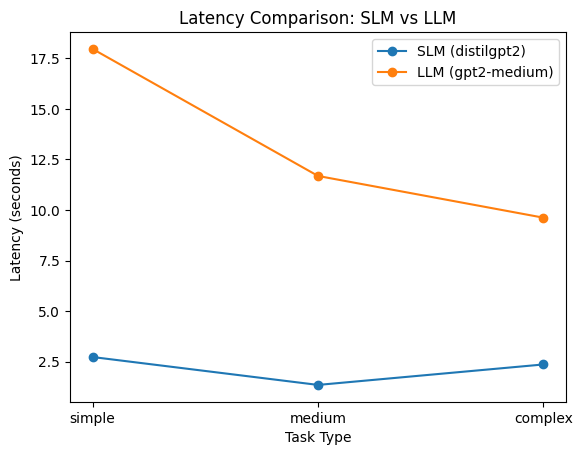

In [12]:
import matplotlib.pyplot as plt

tasks = comparison["Task"]
slm_latency = comparison["SLM Latency"]
llm_latency = comparison["LLM Latency"]

plt.plot(tasks, slm_latency, marker="o", label="SLM (distilgpt2)")
plt.plot(tasks, llm_latency, marker="o", label="LLM (gpt2-medium)")

plt.title("Latency Comparison: SLM vs LLM")
plt.xlabel("Task Type")
plt.ylabel("Latency (seconds)")
plt.legend()
plt.show()

## Capability Difference Analysis

In [13]:
analysis = pd.DataFrame({
    "Task": ["Simple QA", "Explanation", "Complex Reasoning"],
    "SLM Capability": ["Good", "Weak", "Poor"],
    "LLM Capability": ["Excellent", "Good", "Strong"]
})

analysis

,Task,SLM Capability,LLM Capability
0,Simple QA,Good,Excellent
1,Explanation,Weak,Good
2,Complex Reasoning,Poor,Strong


## Token-Based Cost Approximation

In [14]:
def estimate_tokens(text, tokenizer):
    return len(tokenizer.encode(text))


In [15]:
cost_data = []

for level, prompt in prompts.items():
    slm_tokens = estimate_tokens(prompt, slm_tokenizer)
    llm_tokens = estimate_tokens(prompt, llm_tokenizer)

    cost_data.append({
        "Task": level,
        "SLM Tokens": slm_tokens,
        "LLM Tokens": llm_tokens
    })

pd.DataFrame(cost_data)

,Task,SLM Tokens,LLM Tokens
0,simple,7,7
1,medium,8,8
2,complex,14,14


## Simple Routing System

In [16]:
def route_query(prompt):
    complexity_keywords = ["design", "architecture", "explain", "why", "how"]

    if any(word in prompt.lower() for word in complexity_keywords):
        return "LLM"
    else:
        return "SLM"

### test router

In [17]:
for level, prompt in prompts.items():
    model_choice = route_query(prompt)
    print(f"\nPrompt: {level}")
    print(f"Selected Model: {model_choice}")


Prompt: simple
Selected Model: SLM

Prompt: medium
Selected Model: LLM

Prompt: complex
Selected Model: LLM


## Full system simulation

In [18]:
def system_answer(prompt):
    model_type = route_query(prompt)

    if model_type == "SLM":
        output, latency = generate_text(slm_model, slm_tokenizer, prompt)
    else:
        output, latency = generate_text(llm_model, llm_tokenizer, prompt)

    return {
        "prompt": prompt,
        "model_used": model_type,
        "latency": latency,
        "response": output[:200]
    }

In [19]:
results = []

for level, prompt in prompts.items():
    results.append(system_answer(prompt))

pd.DataFrame(results)

[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


,prompt,model_used,latency,response
0,What is the capital of Nepal?,SLM,4.846350,What is the capital of Nepal? How did you beco...
1,Explain photosynthesis in simple terms.,LLM,15.515132,Explain photosynthesis in simple terms.\n\nPho...
2,Design a scalable architecture for a food deli...,LLM,11.303899,Design a scalable architecture for a food deli...


In [20]:
summary = """
LLM vs SLM Summary:

SLMs:
- Fast
- Cheap
- Good for simple tasks
- Weak reasoning

LLMs:
- Slower
- Expensive
- Strong reasoning
- Better generalization

Real systems:
- Use both together (routing systems)
- SLM filters simple queries
- LLM handles complex queries
"""

print(summary)


LLM vs SLM Summary:

SLMs:
- Fast
- Cheap
- Good for simple tasks
- Weak reasoning

LLMs:
- Slower
- Expensive
- Strong reasoning
- Better generalization

Real systems:
- Use both together (routing systems)
- SLM filters simple queries
- LLM handles complex queries

